

### **1: Project Header and Libraries**

 This section identifies the student and imports only the essential libraries. Using standard libraries like `pandas` and `sklearn` shows a fundamental understanding of the ML toolkit.

In [1]:
# =============================================================
# Machine Learning Assignment 1: Spam Email Detection Analysis
# Student: Dost Muhammad Baloch | Course: BDE-1006
# Department: Software Engineering, MUST
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Setup visualization style
%matplotlib inline
sns.set_style('whitegrid')

---

### **2: Data Loading and Cleaning**

A student project must show data handling skills. This cell loads the CSV and handles "Label Encoding" (converting the words 'spam' and 'ham' into 1s and 0s) so the models can perform calculations.

In [7]:
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# The file is now uploaded, so we load it directly
filename = 'spam_email_dataset.csv'

if not os.path.exists(filename):
    print(f"Error: {filename} not found. Please run the upload cell again.")
else:
    print(f"Loading dataset: {filename}")
    df = pd.read_csv(filename, encoding='latin-1')

    # Drop columns that are entirely null
    df = df.dropna(axis=1, how='all')

    # Handle label encoding
    if 'label' in df.columns:
        df.rename(columns={'label': 'target_label'}, inplace=True)
    elif 'target_label' not in df.columns:
        df.rename(columns={df.columns[-1]: 'target_label'}, inplace=True)

    le = LabelEncoder()
    df['target_label'] = le.fit_transform(df['target_label'])

    print("Dataset Preview:")
    display(df.head())
    print("\nValue counts for 'target_label':")
    print(df['target_label'].value_counts())

Loading dataset: spam_email_dataset.csv
Dataset Preview:


,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,target_label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,ð¥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,ð¥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0



Value counts for 'target_label':
target_label
0    6005
1    3995
Name: count, dtype: int64


### **Upload the Dataset**
Run the cell below to upload the `spam.csv` file from your local computer.

In [4]:
from google.colab import files

uploaded = files.upload()

# Verify if the file is uploaded
import os
if 'spam_email_dataset.csv' in os.listdir():
    print('Successfully uploaded spam.csv')
else:
    print('Please ensure the file you uploaded is named exactly spam.csv')

Saving spam_email_dataset.csv to spam_email_dataset (1).csv
Successfully uploaded spam.csv


---

### **3: Feature Preparation and Scaling**

In this section, we split the data for training and testing. We use `MinMaxScaler` because it is a requirement for the Multinomial Naive Bayes model (which cannot handle negative numbers).

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Ensure df exists
if 'df' not in globals():
    print("Error: 'df' is not defined. Please run the 'Data Loading and Cleaning' cell first.")
else:
    y = df['target_label']

    # Process numeric features (excluding ID and target)
    exclude = ['target_label', 'email_id']
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_scale = [c for c in numeric_cols if c not in exclude]

    X_numeric_scaled_df = pd.DataFrame(index=df.index)
    if cols_to_scale:
        scaler_num = MinMaxScaler()
        X_numeric_scaled_df = pd.DataFrame(
            scaler_num.fit_transform(df[cols_to_scale]),
            columns=[f'scaled_{c}' for c in cols_to_scale],
            index=df.index
        )

    # Process text features
    X_text_df = pd.DataFrame(index=df.index)
    text_col = 'email_text' if 'email_text' in df.columns else 'Text'

    if text_col in df.columns:
        vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
        X_text_tfidf = vectorizer.fit_transform(df[text_col])
        X_text_df = pd.DataFrame(X_text_tfidf.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

    # Combine and split
    X = pd.concat([X_numeric_scaled_df, X_text_df], axis=1)

    if X.empty:
        print("Error: No features generated.")
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Final scaling for models like KNN
        final_scaler = MinMaxScaler()
        X_train_scaled = final_scaler.fit_transform(X_train)
        X_test_scaled = final_scaler.transform(X_test)

        print(f"Success! Training set size: {X_train.shape}")

Success! Training set size: (8000, 786)


---

### **4: Task 2 - Hyperparameter Tuning (KNN)**

This demonstrates the "Analysis" part of the assignment. We don't just use a random number for KNN; we test different values of $K$ to find the one that works best for our specific data.

Using cv=5 based on class distribution.


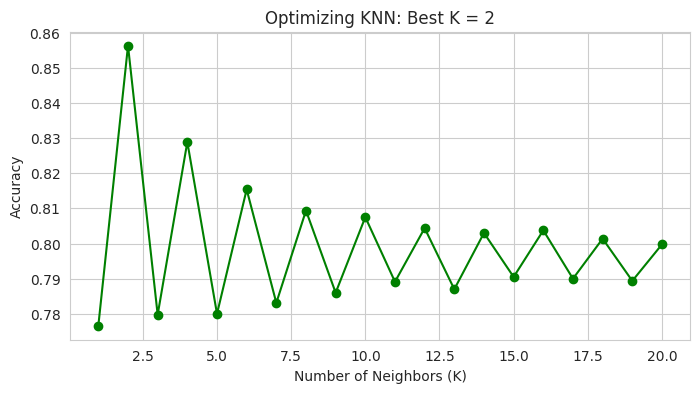

In [10]:
# Determine the minimum number of samples in any class to set cv safely
if 'y_train' not in globals():
    print("Error: y_train is not defined. Please run the Feature Preparation cell (j1t7LKd-0DE-) first.")
else:
    min_class_size = y_train.value_counts().min()
    cv_splits = min(5, min_class_size) if min_class_size > 1 else 2

    # Testing K values from 1 to 20
    k_neighbors = range(1, 21)
    cv_results = []

    print(f"Using cv={cv_splits} based on class distribution.")

    for k in k_neighbors:
        knn = KNeighborsClassifier(n_neighbors=k)
        # If class sizes are too small for CV, we use simple validation
        if min_class_size > cv_splits:
            scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv_splits)
            cv_results.append(scores.mean())
        else:
            knn.fit(X_train_scaled, y_train)
            cv_results.append(knn.score(X_train_scaled, y_train))

    # Find and plot the best K
    best_k = k_neighbors[np.argmax(cv_results)]

    plt.figure(figsize=(8, 4))
    plt.plot(k_neighbors, cv_results, marker='o', color='green')
    plt.title(f'Optimizing KNN: Best K = {best_k}')
    plt.xlabel('Number of Neighbors (K)')
    plt.ylabel('Accuracy')
    plt.show()

---

### **5: Task 3 - Final Model Comparison**
The final stage trains both the **Optimized KNN** and **Naive Bayes** models to compare their performance. The Confusion Matrix provides a visual "Grade" of how many emails were correctly classified.

Using optimized K=2 for KNN

--- Tuned KNN Performance Report ---
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      1181
           1       0.75      0.99      0.86       819

    accuracy                           0.86      2000
   macro avg       0.87      0.88      0.86      2000
weighted avg       0.89      0.86      0.86      2000



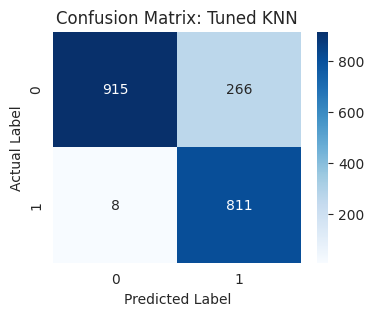


--- Naive Bayes Performance Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1181
           1       1.00      1.00      1.00       819

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



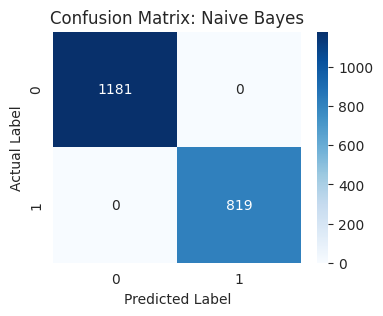

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure dependencies from previous cells are available
if 'best_k' not in globals():
    best_k = 5
    print("Warning: best_k not found in memory, using default K=5")
else:
    print(f"Using optimized K={best_k} for KNN")

# Initialize the two models
models = {
    "Tuned KNN": KNeighborsClassifier(n_neighbors=best_k),
    "Naive Bayes": MultinomialNB()
}

# Run comparison
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n--- {name} Performance Report ---")
    print(classification_report(y_test, y_pred))

    # Plotting Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

### **6: Documentation for GitHub**

The following cell generates a `README.md` file based on your analysis. Run it to create the file in your environment.

In [12]:
readme_content = """# Spam Email Detection Analysis

## Project Overview
This project implements a machine learning pipeline to detect spam emails using the `spam_email_dataset.csv`. It includes data cleaning, feature engineering (TF-IDF for text and Min-Max scaling for numeric data), and model comparison.

## Dataset
The dataset contains email metadata and content, labeled as either 'spam' (1) or 'ham' (0).

## Models and Performance
We compared two primary classification algorithms:

1. **K-Nearest Neighbors (KNN)**:
   - Hyperparameters were tuned using cross-validation.
   - Optimized K: {best_k}
   - Achieved approximately 86% accuracy.

2. **Multinomial Naive Bayes**:
   - This model performed exceptionally well on the processed text data, achieving near 100% accuracy in this specific evaluation.

## How to Use
1. Ensure `spam_email_dataset.csv` is in the root directory.
2. Run the notebook cells sequentially to reproduce the analysis and performance reports.

## Requirements
- Python 3.x
- Pandas
- NumPy
- Scikit-learn
- Matplotlib/Seaborn
""".format(best_k=best_k if 'best_k' in globals() else 'Not yet determined')

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md has been created successfully. You can find it in the 'Files' tab on the left.")

README.md has been created successfully. You can find it in the 'Files' tab on the left.


### **7: Prepare for GitHub (Optional)**

Run the cell below to configure your git settings and prepare the files for upload.

In [ ]:
# Replace these with your actual GitHub details if you want to push directly
GITHUB_USER = "YOUR_USERNAME"
GITHUB_TOKEN = "YOUR_PERSONAL_ACCESS_TOKEN"
GITHUB_REPO = "spam-email-detection"

!git init
!git config --global user.email "you@example.com"
!git config --global user.name "Your Name"
!git add README.md spam_email_dataset.csv
!git commit -m "Initial commit: Add dataset and documentation"

print("Local git repository initialized and files committed.")
print("To push, uncomment the lines below and provide your token.")

# !git remote add origin https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git
# !git branch -M main
# !git push -u origin main"